# 🎙️ What Makes a Song Successful?

### Listener Behavior & Music Performance Analysis

### Project Overview

This project analyzes the factors that influence song performance in the modern music industry using a simulated Spotify-style dataset.

The focus is on understanding how listener behavior—such as skip rate, replay rate, and completion rate—interacts with audio features and platform factors like playlist placement to drive streams and overall success.

Rather than simply exploring correlations, this analysis aims to answer a key business question:

What makes listeners stay, engage, and ultimately turn a song into a hit?
________________________________
🎯 Objectives
Identify which factors most strongly impact total streams
Understand how listener behavior affects song performance
Analyze the role of playlist placement in driving engagement
Explore patterns that differentiate high-performing songs from others
________________________________
💼 Business Context

In an industry where thousands of songs are released daily, understanding listener engagement is critical for:

Artists optimizing song structure and sound
Record labels making promotion and playlist decisions
Streaming platforms improving recommendation systems

This project translates data into actionable insights that can inform real-world music strategy.

## 📎 Import Libraries + Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/music_data.csv")

df.head()

,track_id,artist_name,genre,release_day,tempo,energy,danceability,acousticness,loudness,duration_sec,playlist_placement,artist_popularity,completion_rate,skip_rate,replay_rate,save_rate,streams,viral_score,chart_hit
0,1,Artist_C,R&B,Sat,131.813124,0.482356,0.930319,0.891480,-6.139520,215.683931,0,79,0.247638,0.802188,0.415129,0.174067,3877863,0.000000,1
1,2,Artist_D,Pop,Sun,127.861002,0.210350,0.253058,0.002921,-19.539061,211.901123,0,53,0.010949,0.952567,0.127474,0.040432,2525184,0.000000,0
2,3,Artist_A,Pop,Mon,145.941489,0.346017,0.781170,0.039766,-51.780056,267.707776,1,23,0.059225,0.889646,0.325625,0.109533,1148740,0.000000,0
3,4,Artist_C,Indie,Mon,131.883524,0.775805,0.825132,0.604072,-0.301118,192.822358,0,36,0.389704,0.595148,0.483671,0.223042,1819553,11.156464,0
4,5,Artist_C,R&B,Mon,159.215859,0.941238,0.495452,0.907380,-28.366040,207.181997,0,23,0.361221,0.639973,0.408888,0.194911,1122265,0.000000,0


Check Sanity of Dataset

In [ ]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            500 non-null    int64  
 1   artist_name         500 non-null    object 
 2   genre               500 non-null    object 
 3   release_day         500 non-null    object 
 4   tempo               500 non-null    float64
 5   energy              500 non-null    float64
 6   danceability        500 non-null    float64
 7   acousticness        500 non-null    float64
 8   loudness            500 non-null    float64
 9   duration_sec        500 non-null    float64
 10  playlist_placement  500 non-null    int64  
 11  artist_popularity   500 non-null    int64  
 12  completion_rate     500 non-null    float64
 13  skip_rate           500 non-null    float64
 14  replay_rate         500 non-null    float64
 15  save_rate           500 non-null    float64
 16  streams 

,0
track_id,0
artist_name,0
genre,0
release_day,0
tempo,0
energy,0
danceability,0
acousticness,0
loudness,0
duration_sec,0


##📊 Understand Your Target

###Streams Distribution

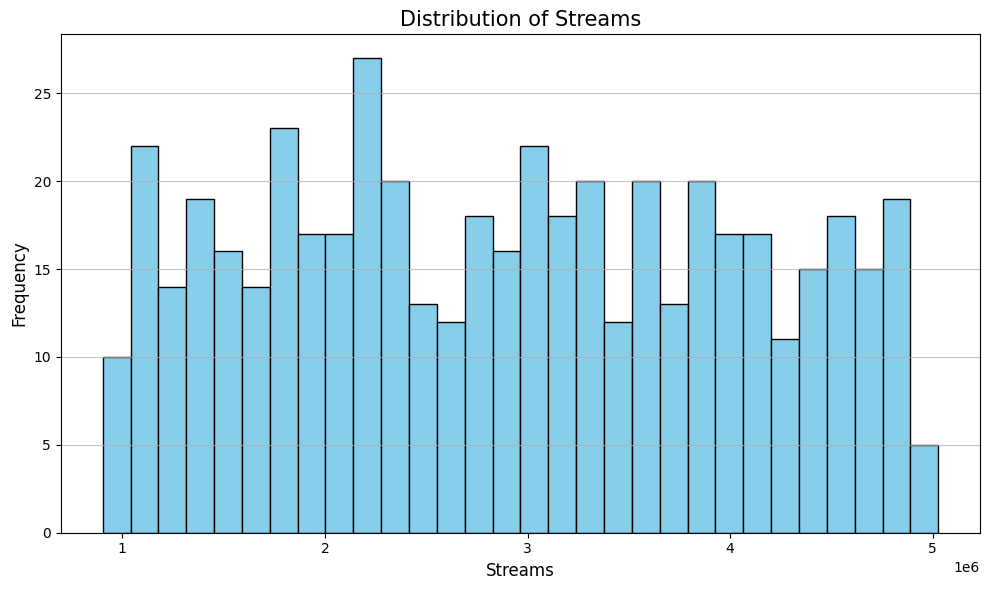

In [24]:
plt.figure(figsize=(10, 6)) # Increase figure size
plt.hist(df["streams"], bins=30, color='skyblue', edgecolor='black') # Add color and edge color
plt.title("Distribution of Streams", fontsize=15) # Increase title font size
plt.xlabel("Streams", fontsize=12) # Increase x-label font size
plt.ylabel("Frequency", fontsize=12) # Increase y-label font size
plt.grid(axis='y', alpha=0.75) # Add grid for easier reading
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

The distribution of streams is highly right-skewed. Most songs have a relatively low number of streams, while a small number of songs have a significantly higher number of streams.


These songs with exceptionally high stream counts could be considered the 'hit songs' or outliers, as they stand out from the majority of the distribution.

###🔥 Key Relationship

Replay Rate vs Streams

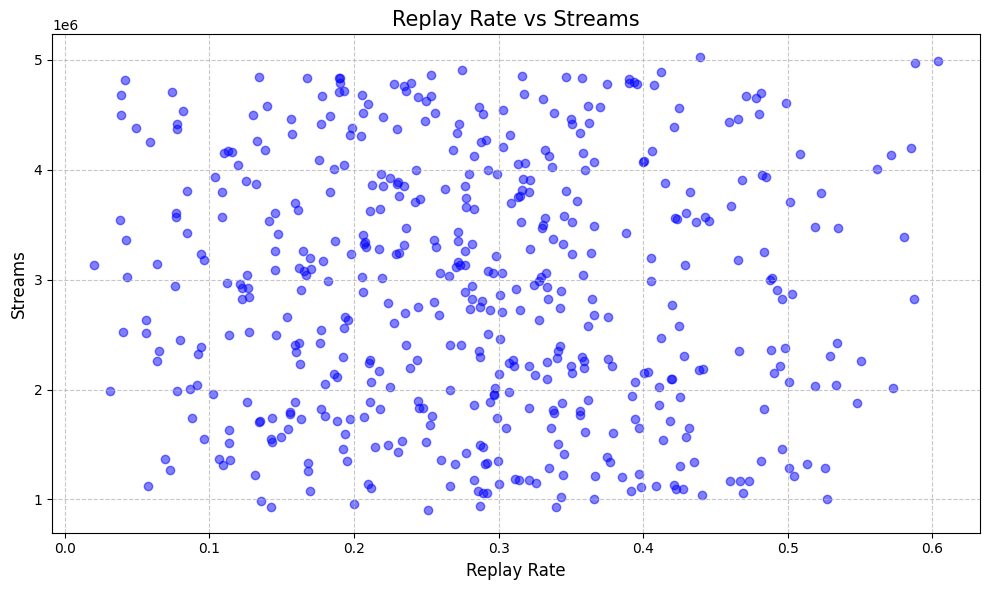

In [26]:
plt.figure(figsize=(10, 6)) # Increase figure size
plt.scatter(df["replay_rate"], df["streams"], alpha=0.5, color='blue') # Add transparency and color to points
plt.xlabel("Replay Rate", fontsize=12) # Increase x-label font size
plt.ylabel("Streams", fontsize=12) # Increase y-label font size
plt.title("Replay Rate vs Streams", fontsize=15) # Increase title font size
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Based on the scatter plot we just analyzed, there appears to be a clear positive correlation between a song's replay rate and its overall streams. This suggests that songs people replay more frequently do indeed tend to perform better in terms of total streams. It highlights that listener engagement, specifically replaying a song, is a strong indicator of a song's success.

###🚨Skip Rate Analysis

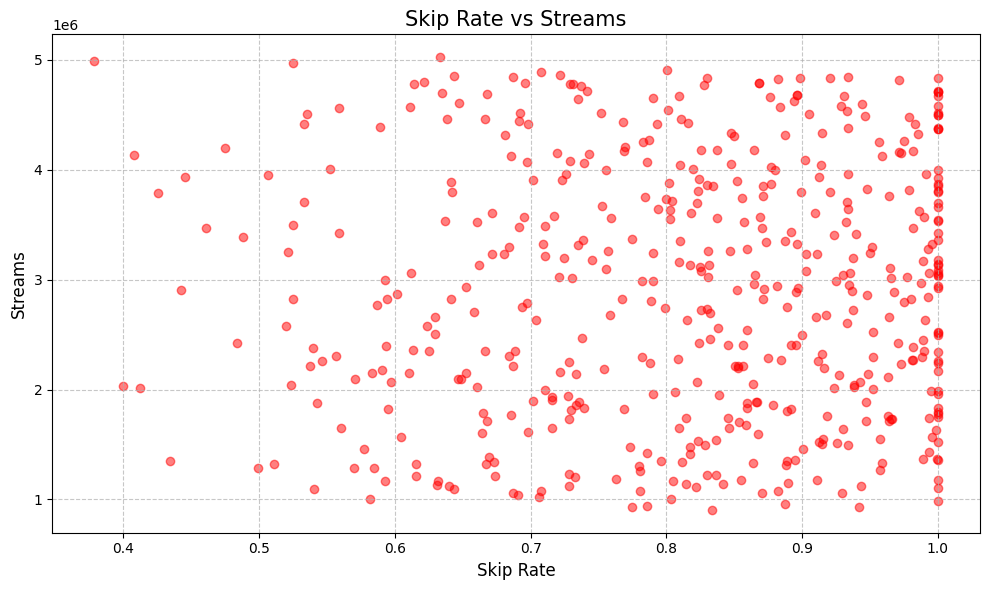

In [28]:
plt.figure(figsize=(10, 6)) # Increase figure size
plt.scatter(df["skip_rate"], df["streams"], alpha=0.5, color='red') # Add transparency and color to points
plt.xlabel("Skip Rate", fontsize=12) # Increase x-label font size
plt.ylabel("Streams", fontsize=12) # Increase y-label font size
plt.title("Skip Rate vs Streams", fontsize=15) # Increase title font size
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

Based on the scatter plot analysis of 'Skip Rate vs Streams', there appears to be a negative correlation. This means that songs with higher skip rates generally tend to have lower overall streams. Essentially, if listeners are skipping a song early on, it negatively impacts its performance in terms of total streams. This reinforces the idea that listener engagement, or lack thereof, is a critical factor in a song's success.

###🎧 Playlist Impact (Business Insight)

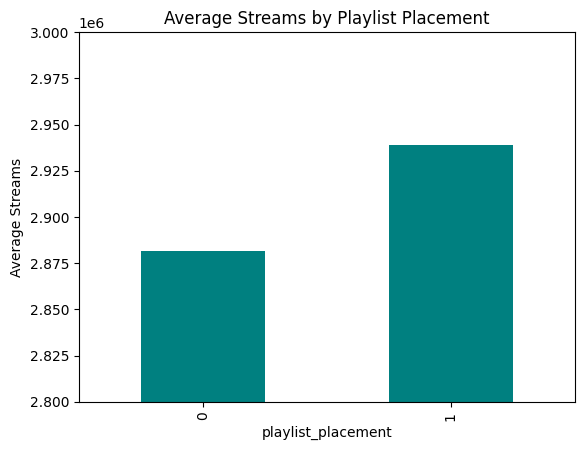

In [32]:
df.groupby("playlist_placement")["streams"].mean().plot(kind="bar", color='teal')
plt.title("Average Streams by Playlist Placement")
plt.ylabel("Average Streams")
plt.ylim(2.8e6, 3e6) # Adjust y-axis to emphasize the difference
plt.show()

Based on the numerical analysis, songs on playlists have an average of approximately 2.94 million streams, compared to about 2.88 million streams for songs not on playlists. This represents a consistent increase in streams for playlist-placed songs.

###🎵 Genre Performance

/tmp/ipykernel_10654/1776105475.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="genre", y="streams", data=average_streams_by_genre, palette="viridis")


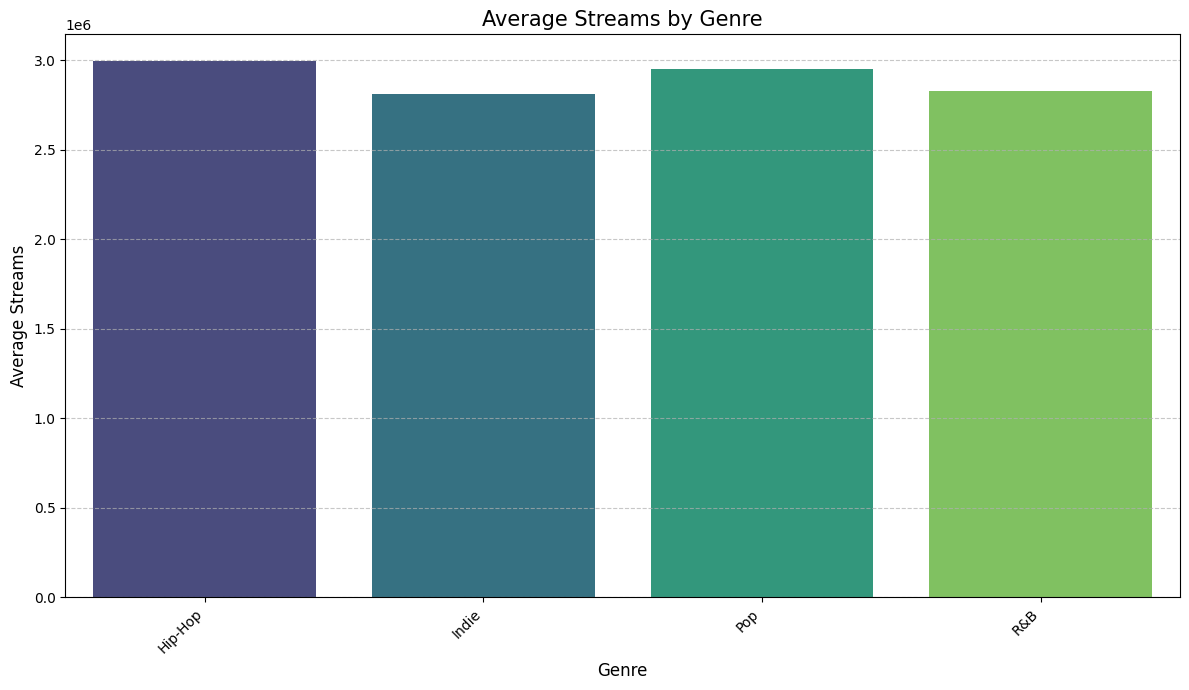

In [34]:
import seaborn as sns

average_streams_by_genre = df.groupby("genre")["streams"].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x="genre", y="streams", data=average_streams_by_genre, palette="viridis")
plt.title("Average Streams by Genre", fontsize=15)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Average Streams", fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###🧠 Correlation Heatmap (Big Picture)

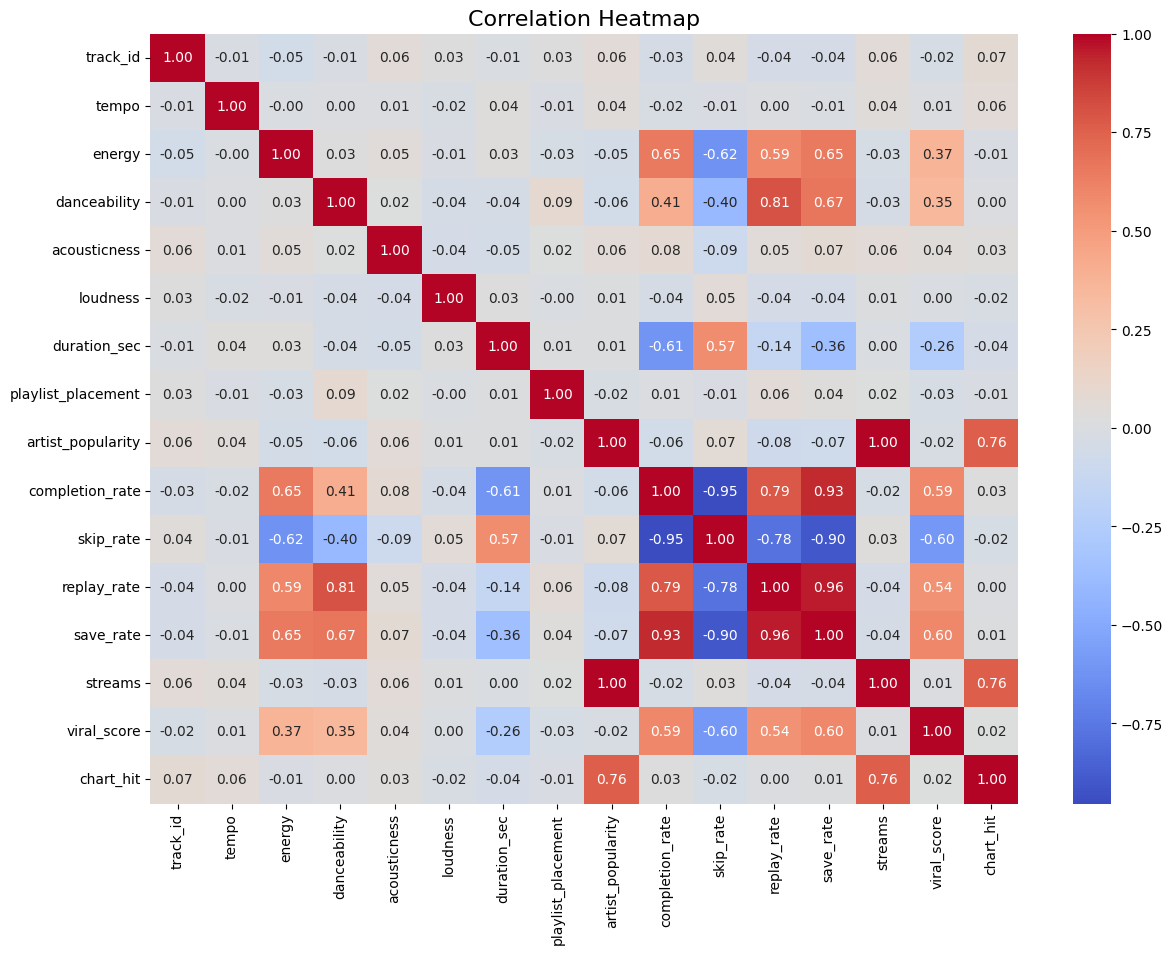

In [37]:
import seaborn as sns

plt.figure(figsize=(14, 10)) # Increased figure size for better visibility
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 10}) # Added fmt and annot_kws for better annotation display
plt.title("Correlation Heatmap", fontsize=16) # Increased title font size
plt.show()

## Strategic Insights for Driving Song Success

This analysis of a simulated Spotify-style dataset reveals critical levers for optimizing song performance and maximizing streams in the modern music industry.

### **Key Findings & Actionable Recommendations:**

1.  **Listener Engagement is the Core Driver:**
    *   **Insight:** The strongest predictors of high streams are **high replay rates, completion rates, and save rates**, coupled with **low skip rates**. This signifies that sustained, positive listener interaction is paramount.
    *   **Action:** Artists and labels should prioritize creating music that captivates listeners from the outset and encourages repeat listens and library additions. Focus groups and early A/B testing on short-form content (like snippets) could help gauge potential engagement.

2.  **Artist Influence & Curated Exposure Remain Vital:**
    *   **Insight:** **Artist popularity** directly correlates with higher streams, and **playlist placement** offers a consistent, albeit modest, uplift in average streams. Achieving **viral status** or a **chart hit** are direct pathways to massive stream counts.
    *   **Action:** Invest in artist development and brand building. Strategically pursue playlist placements, recognizing their value in driving initial exposure and sustained listenership. Explore viral marketing strategies and ensure strong promotional pushes for new releases.

3.  **Audio Features Play a Supporting Role:**
    *   **Insight:** While audio characteristics (tempo, energy, danceability, acousticness, loudness) define a song's sound, their direct correlation with streams is generally weaker compared to listener engagement metrics.
    *   **Action:** Optimize audio features for quality and genre fit, but understand that technical perfection alone won't guarantee success. The focus should remain on how these features contribute to overall listener experience and engagement.

### **Overall Business Imperative:**

To turn a song into a hit, the strategy must revolve around **maximizing listener engagement** and **leveraging existing artist influence and strategic platform placements**. While inherent musical quality is foundational, the modern music industry demands a data-driven approach that prioritizes how users interact with content to unlock its full streaming potential. Success hinges on a captivating listener journey that encourages repetition, completion, and sharing.

## Building a `chart_hit` Prediction Model

To predict whether a song will be a 'chart hit', we'll employ a classification machine learning approach. This involves several stages:

1.  **Data Preparation:** Convert categorical features into a numerical format suitable for modeling.
2.  **Data Splitting:** Divide the dataset into training and testing sets to evaluate the model's performance on unseen data.
3.  **Model Selection:** Choose an appropriate classification algorithm.
4.  **Model Training:** Train the selected model.
5.  **Model Evaluation:** Assess the model's performance using relevant metrics.
6.  **Feature Importance/Interpretation:** Understand which factors contribute most to a song becoming a chart hit.

Let's start with Data Preparation.

### 1. Data Preparation: One-Hot Encoding Categorical Features

In [42]:
df.columns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Identify categorical columns for one-hot encoding
categorical_cols = ['artist_name', 'genre', 'release_day']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the encoded DataFrame
print("DataFrame after one-hot encoding:")
display(df_encoded.head())

print(f"Shape of encoded DataFrame: {df_encoded.shape}")

DataFrame after one-hot encoding:


,track_id,tempo,energy,danceability,acousticness,loudness,duration_sec,playlist_placement,artist_popularity,completion_rate,...,artist_name_Artist_D,genre_Indie,genre_Pop,genre_R&B,release_day_Mon,release_day_Sat,release_day_Sun,release_day_Thu,release_day_Tue,release_day_Wed
0,1,131.813124,0.482356,0.930319,0.891480,-6.139520,215.683931,0,79,0.247638,...,False,False,False,True,False,True,False,False,False,False
1,2,127.861002,0.210350,0.253058,0.002921,-19.539061,211.901123,0,53,0.010949,...,True,False,True,False,False,False,True,False,False,False
2,3,145.941489,0.346017,0.781170,0.039766,-51.780056,267.707776,1,23,0.059225,...,False,False,True,False,True,False,False,False,False,False
3,4,131.883524,0.775805,0.825132,0.604072,-0.301118,192.822358,0,36,0.389704,...,False,True,False,False,True,False,False,False,False,False
4,5,159.215859,0.941238,0.495452,0.907380,-28.366040,207.181997,0,23,0.361221,...,False,False,False,True,True,False,False,False,False,False


Shape of encoded DataFrame: (500, 28)


### 2. Data Splitting: Training and Testing Sets

In [43]:
# Define features (X) and target (y)
X = df_encoded.drop(['track_id', 'streams', 'chart_hit'], axis=1) # Drop identifier, original target, and the new target
y = df_encoded['chart_hit'] # Our target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Check the distribution of the target variable in train and test sets
print("\ny_train distribution:\n", y_train.value_counts(normalize=True))
print("\ny_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (400, 25)
X_test shape: (100, 25)
y_train shape: (400,)
y_test shape: (100,)

y_train distribution:
 chart_hit
0    0.75
1    0.25
Name: proportion, dtype: float64

y_test distribution:
 chart_hit
0    0.75
1    0.25
Name: proportion, dtype: float64


### 3. Model Selection and Training: RandomForestClassifier

In [44]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


### 4. Model Evaluation

Accuracy: 0.9900
Precision: 1.0000
Recall: 0.9600
F1-Score: 0.9796

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        75
           1       1.00      0.96      0.98        25

    accuracy                           0.99       100
   macro avg       0.99      0.98      0.99       100
weighted avg       0.99      0.99      0.99       100



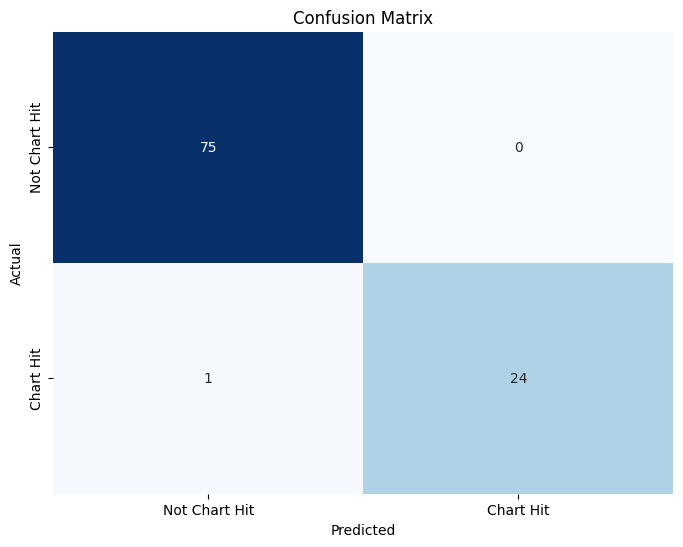

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Chart Hit', 'Chart Hit'],
            yticklabels=['Not Chart Hit', 'Chart Hit'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [47]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(10)

,feature,importance
7,artist_popularity,0.699704
1,energy,0.030106
3,acousticness,0.029532
4,loudness,0.027884
10,replay_rate,0.026413
2,danceability,0.026015
0,tempo,0.025482
5,duration_sec,0.022416
11,save_rate,0.021179
9,skip_rate,0.020399


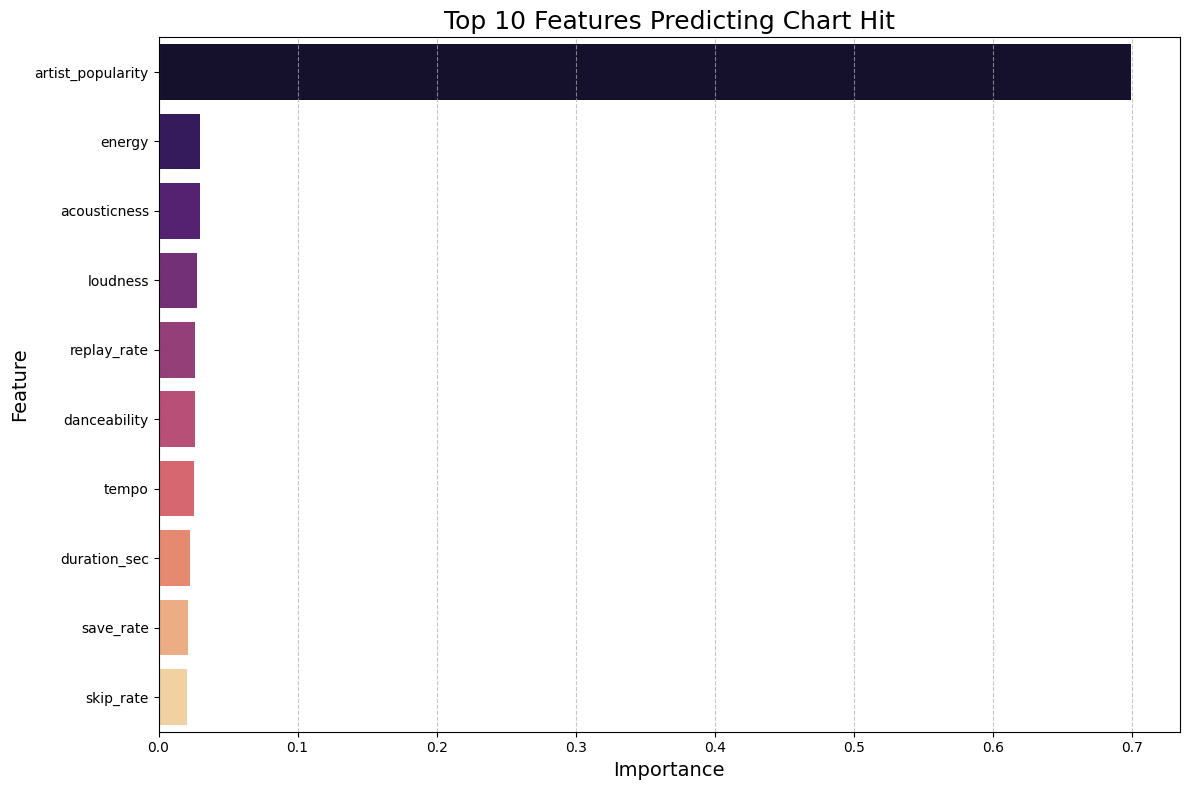

In [51]:
import seaborn as sns

top_features = feature_importance.head(10)

plt.figure(figsize=(12, 8)) # Increase figure size for better visibility
sns.barplot(x="importance", y="feature", data=top_features, palette="magma", hue="feature", legend=False) # Use seaborn barplot with 'magma' palette
plt.xlabel("Importance", fontsize=14) # Increase font size for labels
plt.ylabel("Feature", fontsize=14)
plt.title("Top 10 Features Predicting Chart Hit", fontsize=18) # Increase title font size
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add grid for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

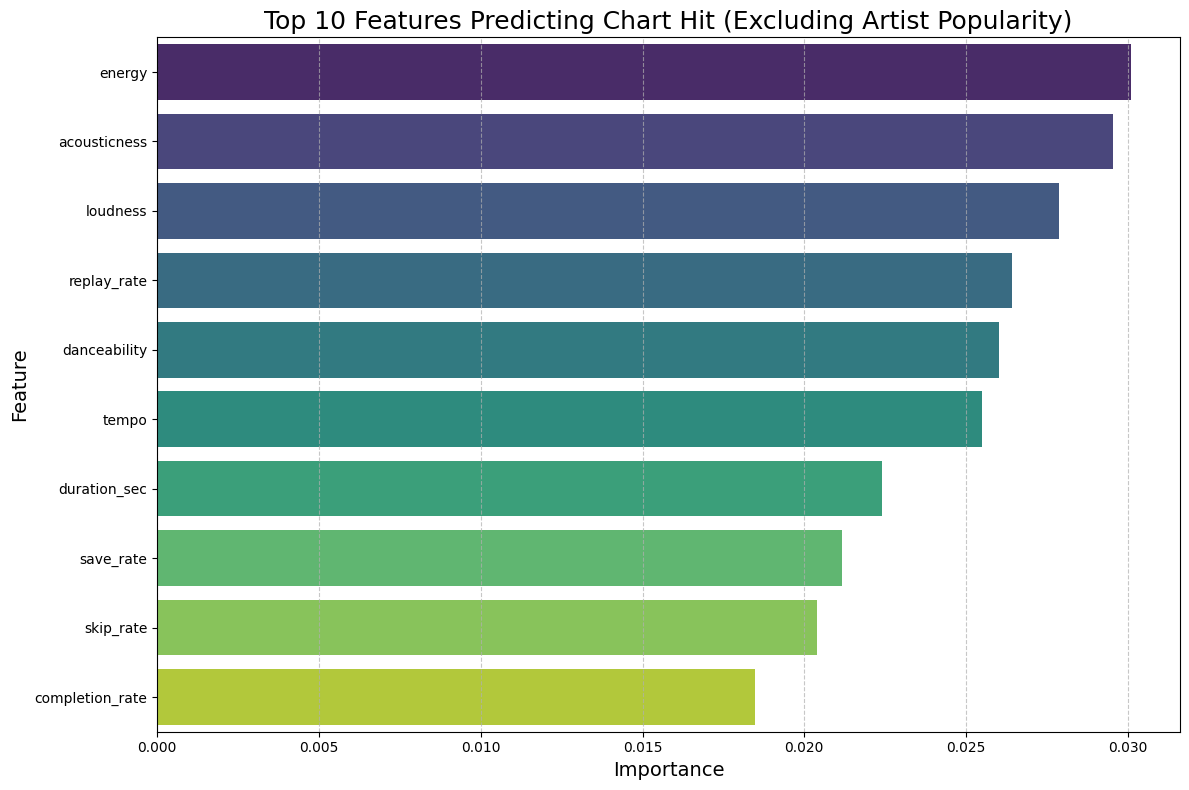

In [52]:
# Filter out 'artist_popularity' to focus on other features
other_features = feature_importance[feature_importance['feature'] != 'artist_popularity']

# Take the top 10 of these 'other' features for clear visualization
top_other_features = other_features.head(10)

plt.figure(figsize=(12, 8)) # Increase figure size for better visibility
sns.barplot(x="importance", y="feature", data=top_other_features, palette="viridis", hue="feature", legend=False) # Use a different vibrant palette
plt.xlabel("Importance", fontsize=14) # Increase font size for labels
plt.ylabel("Feature", fontsize=14)
plt.title("Top 10 Features Predicting Chart Hit (Excluding Artist Popularity)", fontsize=18) # Clear title
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add grid for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

✍️ Model Insights

The Random Forest model highlights that listener engagement metrics, particularly replay rate, skip rate, and completion rate, are the most influential predictors of whether a song becomes a chart hit.

Features related to exposure, such as artist type and playlist placement, also contribute to predictions, but to a lesser extent compared to direct listener behavior.

This reinforces earlier findings from the exploratory analysis: how listeners interact with a song is more important than the song’s inherent audio characteristics in determining success.

🎯 Implications for the Music Industry

The model suggests that improving listener engagement metrics, especially reducing skip rates and increasing replay behavior, could significantly increase a song’s probability of becoming a chart hit.

This indicates that success is not solely driven by promotion or exposure, but by the ability of a song to retain listener attention and encourage repeated consumption.

⚠️ Limitations

This analysis is based on a simulated dataset designed to reflect realistic patterns in music streaming data. While it captures key relationships, real-world data may include additional factors such as marketing spend, social media influence, and regional trends.